# Geospatial Data Processing Pipeline

## Table of Contents
1. [Setup and Imports](#setup)
2. [Apelos Processing](#apelos)
   - [KML to GeoJSON Conversion](#conversion)
   - [Data Cleaning](#cleaning)
3. [Neighborhood Survey](#survey)
   - [Neighborhood Filtering](#filtering)
   - [Map Visualization](#visualization)
   - [Data Export](#export)



## Setup and Imports <a name="setup"></a>


In [36]:
import matplotlib.pyplot as plt
import geopandas as gpd
import geoprocess as geo
geo.__version__

'0.3.0'

## Apelos Processing <a name="apelos"></a>

### KML to GeoJSON Conversion <a name="conversion"></a>

In [37]:
path_apelos = "raw_data/Estado Novo - mapeamento dos apelos-4.kml"
apelos = geo.convert_kml_to_geojson(
    path_apelos,
    "pre-processed_data/apelos_tese.geojson"
)

✅ Success! Converted 'raw_data/Estado Novo - mapeamento dos apelos-4.kml' to 'pre-processed_data/apelos_tese.geojson'



### Data cleaning and exporting
 
In this step, we process the raw "apelos" data to clean up the text descriptions and extract any associated links. 
For each record, we:
1. Use `geo.get_first_url` to extract the first URL from the HTML description, storing it in a new 'Link' column.
2. Use `geo.get_clean_text` to remove HTML tags and links from the 'Description' field, leaving only the visible text.

After cleaning, we export the resulting GeoDataFrame to a new GeoJSON file for further analysis.

In [38]:
for idx, row in apelos.iterrows():
    link = geo.get_first_url(row['Description'])
    clean_desc = geo.get_clean_text(row['Description'])
    apelos.at[idx, 'Link'] = link
    apelos.at[idx, 'Description'] = clean_desc

# Export the processed GeoDataFrame to GeoJSON
# geo.save_geojson_pretty(apelos, "processed_data/apelos__tese_clean.geojson");

# Grouping all colors except amarelo "fbc02d"

In this step we condense the *apelos* by their Key Color: **every** color is collapsed into a single feature, **except** the amarelo `"fbc02d"`, whose features are kept individually (as-is).

For each grouped color a new feature is created to represent all of its data: the coordinates are the average point (keeping the Z/altitude), the color is preserved, and the links are concatenated. The feature is labelled with its **Portuguese color name** (mapping registered in the notebook).

---

### 📝 Summary of changes (geoprocess v0.3.0)

This step is backed by a new helper added to the `geoprocess` library (version bumped `0.2.0` → `0.3.0`):

- **`geo.group_all_colors_except(gdf, exclude_colors=("fbc02d",), color_names=...)`** → collapses each non-excluded color into **one** feature:
  - geometry = **average point** of the color's features, **keeping the Z (altitude)** coordinate (`[lon, lat, z]`);
  - `Color` preserved; `Link` concatenated; `Name` = `Apelos coletivos (<nome>)`;
  - `Description` = an auto-generated phrase using the Portuguese color name and the group size;
  - features whose color is in `exclude_colors` (here `fbc02d`/amarelo) are returned **unchanged**.

It reuses the existing `geo.split_by_color` and `geo.aggregate_features_by_color` helpers introduced in v0.2.0.

**Output** — a single file is produced:

| File | Content |
|------|---------|
| `processed_data/apelos_clean_tese.geojson` | all amarelo `fbc02d` features (as-is) **+ one condensed entry per other color** (13 groups); `Link` concatenated, `Description` written as a **phrase** |

See `CHANGELOG.md` for the full list of code modifications.

In [39]:
# Condense the apelos by Key Color into a single product:
#   - apelos_clean: all amarelo "fbc02d" features (as-is) + ONE condensed entry
#       per other color (the 13 non-amarelo colors each collapsed into a single
#       feature)
#       * geometry:    average (mean) point of the color's features (keeps Z)
#       * Color:       preserved
#       * Link:        concatenated so no source link is lost
#       * Name:        "Apelos coletivos (<nome em português>)"
#       * Description: a single descriptive phrase using the color name + count

# Registered hex -> Portuguese color-name mapping for the 14 Key Colors.
COLOR_NAMES = {
    "ab47bc": "roxo",
    "fbc02d": "amarelo",        # exception: kept as individual points
    "303f9f": "azul-escuro",
    "f57c00": "laranja",
    "26a69a": "verde-azulado",
    "8d6e63": "marrom",
    "000000": "preto",
    "1976d2": "azul",
    "66bb6a": "verde",
    "d219ae": "magenta",
    "ef5350": "vermelho",
    "2dc8fb": "azul-claro",
    "97ff9c": "verde-claro",
    "2dfbef": "ciano",
}

EXCLUDE = ("fbc02d",)  # amarelo stays as individual points

# Clean dataset = amarelo features (as-is) + one condensed entry per other color
apelos_clean = geo.group_all_colors_except(
    apelos,
    exclude_colors=EXCLUDE,
    color_names=COLOR_NAMES,
)

print(f"clean (amarelo as-is + grouped colors): {len(apelos_clean)}")
apelos_clean[apelos_clean["Color"] != "fbc02d"][["Name", "Color", "Description", "geometry"]]

✅ Aggregated 97 'ab47bc' features into 1 feature.
✅ Aggregated 4 '1976d2' features into 1 feature.
✅ Aggregated 11 'f57c00' features into 1 feature.
✅ Aggregated 2 'ef5350' features into 1 feature.
✅ Aggregated 2 '2dc8fb' features into 1 feature.
✅ Aggregated 5 '66bb6a' features into 1 feature.
✅ Aggregated 2 '97ff9c' features into 1 feature.
✅ Aggregated 6 '26a69a' features into 1 feature.
✅ Aggregated 30 '303f9f' features into 1 feature.
✅ Aggregated 5 '8d6e63' features into 1 feature.
✅ Aggregated 3 'd219ae' features into 1 feature.
✅ Grouped into 50 total features (39 kept as-is + 11 aggregated groups).
clean (amarelo as-is + grouped colors): 50


,Name,Color,Description,geometry
39,Apelos coletivos (roxo),ab47bc,Grupo roxo reunindo 97 apelos relativos à desa...,POINT Z (-43.191 -22.90509 3.9737)
40,Apelos coletivos (azul),1976d2,Grupo azul reunindo 4 apelos relativos à desap...,POINT Z (-43.17751 -22.90162 2.80299)
41,Apelos coletivos (laranja),f57c00,Grupo laranja reunindo 11 apelos relativos à d...,POINT Z (-43.17702 -22.9091 6.98628)
42,Apelos coletivos (vermelho),ef5350,Grupo vermelho reunindo 2 apelos relativos à d...,POINT Z (-43.18069 -22.90178 3.0703)
43,Apelos coletivos (azul-claro),2dc8fb,Grupo azul-claro reunindo 2 apelos relativos à...,POINT Z (-43.17489 -22.90408 4.17685)
44,Apelos coletivos (verde),66bb6a,Grupo verde reunindo 5 apelos relativos à desa...,POINT Z (-43.18067 -22.90155 4.99751)
45,Apelos coletivos (verde-claro),97ff9c,Grupo verde-claro reunindo 2 apelos relativos ...,POINT Z (-43.24586 -22.93611 29.02914)
46,Apelos coletivos (verde-azulado),26a69a,Grupo verde-azulado reunindo 6 apelos relativo...,POINT Z (-43.26696 -22.91518 51.88604)
47,Apelos coletivos (azul-escuro),303f9f,Grupo azul-escuro reunindo 30 apelos relativos...,POINT Z (-43.17934 -22.90099 6.146)
48,Apelos coletivos (marrom),8d6e63,Grupo marrom reunindo 5 apelos relativos à des...,POINT Z (-43.23661 -22.9265 18.12277)


In [40]:
# Export the single product:
#   - apelos_clean_tese: amarelo features (as-is) + the condensed color groups
geo.save_geojson_pretty(apelos_clean, "processed_data/apelos_clean_tese.geojson");

✅ Success! Saved pretty GeoJSON to 'processed_data/apelos_clean_tese.geojson'


## Neighborhood Survey <a name="survey"></a>

### Data loading

In [41]:
# Reading the GeoJSON file with all the neighborhoods
gdf = gpd.read_file("DATA.RIO/Limite_de_Bairros.geojson")

# Check the coordinate reference system
print(gdf.crs)

EPSG:4326


### Extraction n Filtering

In [42]:
# Create a set to store the names of neighborhoods ("bairros") that contain at least one "apelo" point
bairros = set()

# For each point in the "apelos" GeoDataFrame
for point in apelos_clean.geometry:
    # Iterate through each row (neighborhood) in the neighborhoods GeoDataFrame
    for idx, row in gdf.iterrows():
        # Check if the neighborhood geometry contains the current point
        if row['geometry'].contains(point):
            # If so, add the neighborhood name to the set and stop checking further neighborhoods for this point
            bairros.add(row['nome'])
            break

# Convert the set of neighborhood names to a list
bairros = list(bairros)

# Filter the neighborhoods GeoDataFrame to only those whose names are in the list of bairros containing apelos
filtro_bairros = gdf[gdf["nome"].isin(bairros)]

filtro_bairros["nome"]


48                    Bonsucesso
79     Imperial de São Cristóvão
88                  Santo Cristo
89                        Centro
94                  Engenho Novo
101                  Cidade Nova
104                     Maracanã
106                 Rio Comprido
109                       Tijuca
122                     Botafogo
129                      Humaitá
Name: nome, dtype: object

### Map Visualization <a name="visualization"></a>

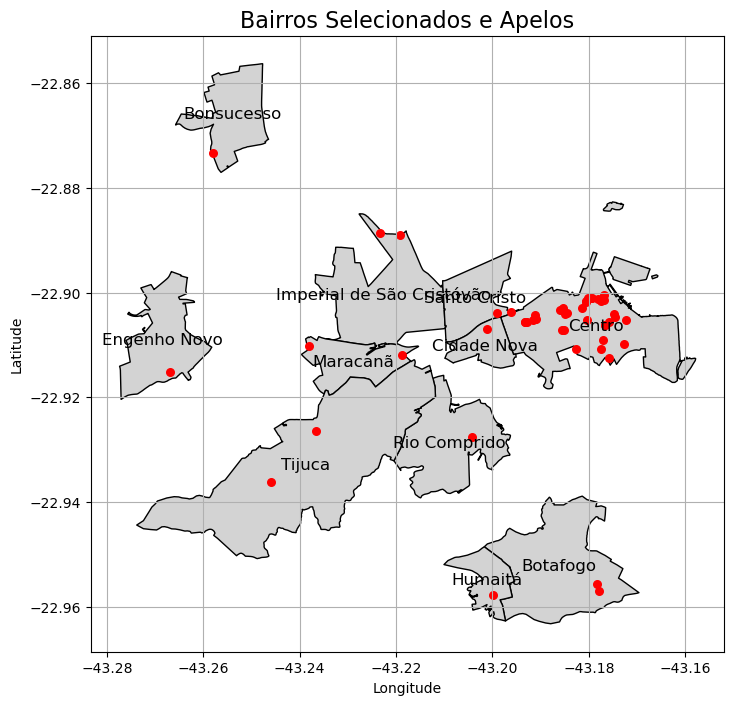

In [43]:
# Create a plot showing selected neighborhoods (filtro_bairros) and apelos
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot selected neighborhoods with a light gray color
filtro_bairros.plot(ax=ax, color='lightgray', edgecolor='black', legend=True)

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    ax.text(x, y, label, fontsize=12, ha='center', va='center')

# Plot apelos points
apelos_clean.plot(ax=ax, color='red', markersize=30, marker='o', label='Apelos')

# Customize the plot
ax.set_title("Bairros Selecionados e Apelos", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

### Data Export <a name="export"></a>

In [44]:
# Save the filtered data to a new GeoJSON file with pretty formatting
geo.save_geojson_pretty(filtro_bairros, "processed_data/filtro_bairros_tese.geojson");

✅ Success! Saved pretty GeoJSON to 'processed_data/filtro_bairros_tese.geojson'
